
The loan dataset used was acquired from Kaggle: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [490]:
import pandas as pd

In [491]:
df = pd.read_csv("/content/loan_data.csv")

In [492]:
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [493]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [494]:
df.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [495]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='person_gender', ylabel='count'>

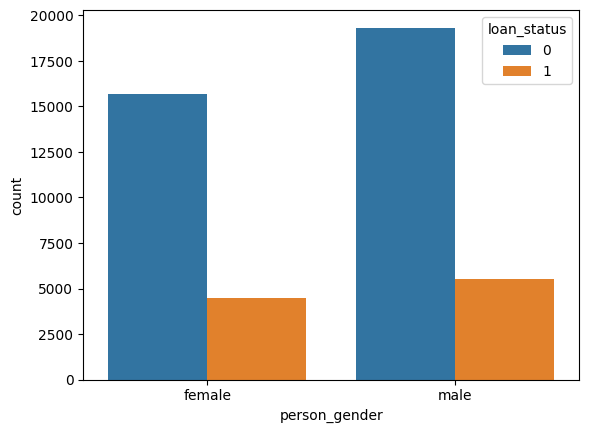

In [496]:
sns.countplot(data=df,x="person_gender",hue="loan_status")

<Axes: xlabel='person_education', ylabel='count'>

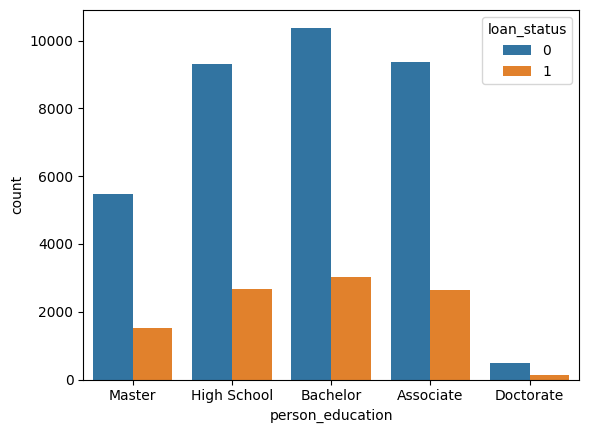

In [497]:
sns.countplot(data=df,x="person_education",hue="loan_status")

<Axes: xlabel='person_age', ylabel='loan_status'>

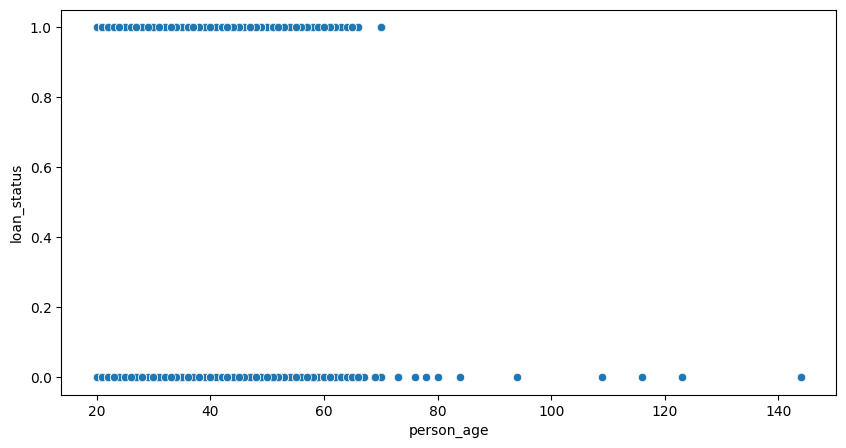

In [498]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df,y="loan_status",x="person_age")

<Axes: xlabel='person_income', ylabel='loan_status'>

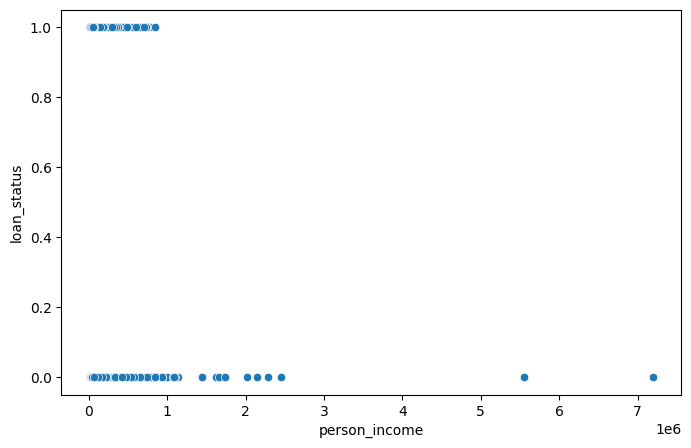

In [499]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,y="loan_status",x="person_income")

<Axes: xlabel='loan_status', ylabel='person_emp_exp'>

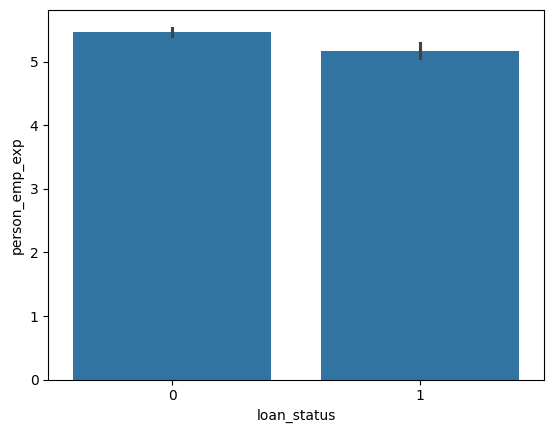

In [500]:
sns.barplot(data=df,x="loan_status",y="person_emp_exp")

<Axes: xlabel='loan_status', ylabel='person_income'>

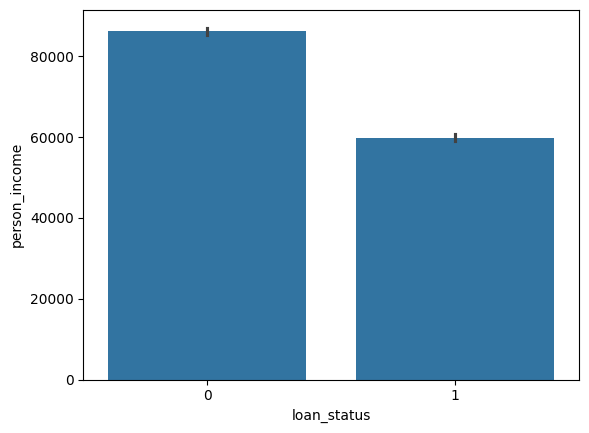

In [501]:
sns.barplot(data=df,x="loan_status",y="person_income")

<Axes: xlabel='loan_status', ylabel='person_emp_exp'>

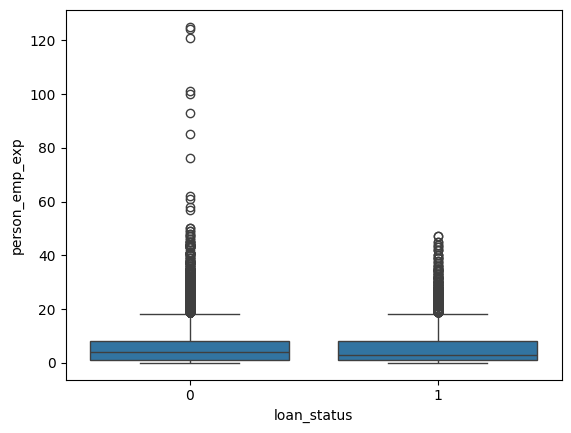

In [502]:
sns.boxplot(data=df,x="loan_status",y="person_emp_exp")

In [503]:
df.groupby("loan_status")["person_emp_exp"].agg("max")

,person_emp_exp
loan_status,
0,125
1,47


In [504]:
df.groupby("loan_status")["person_age"].agg("max")

,person_age
loan_status,
0,144.0
1,70.0


In [505]:
df = df[(df['person_age'] <= 80) | (df['person_emp_exp'] <= 50)]

In [506]:
for t in [500_000, 1_000_000, 2_000_000, 5_000_000]:
    print(t, (df['person_income'] > t).sum())

500000 101
1000000 21
2000000 4
5000000 0


In [507]:
df.groupby("person_education")["person_income"].agg("max")

,person_income
person_education,
Associate,1741243.0
Bachelor,1440915.0
Doctorate,1440982.0
High School,2448661.0
Master,1080918.0


In [508]:
idx = df.groupby("loan_status")["person_income"].idxmax()
df.loc[idx, ["loan_status", "person_income", "person_education","person_gender"]]

,loan_status,person_income,person_education,person_gender
30049,0,2448661.0,High School,male
25714,1,845636.0,Bachelor,male


<Axes: xlabel='loan_status', ylabel='cb_person_cred_hist_length'>

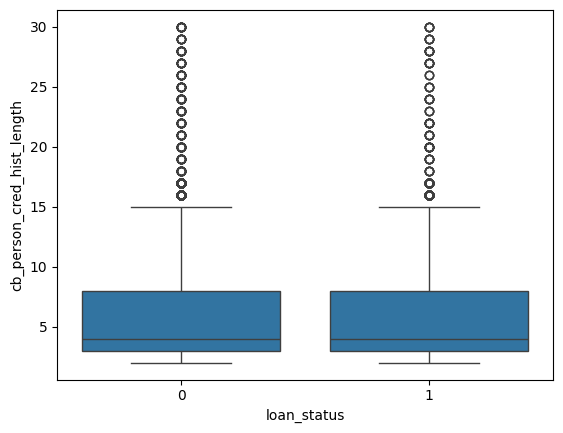

In [509]:
sns.boxplot(data=df,x="loan_status",y="cb_person_cred_hist_length")

<Axes: xlabel='loan_status', ylabel='count'>

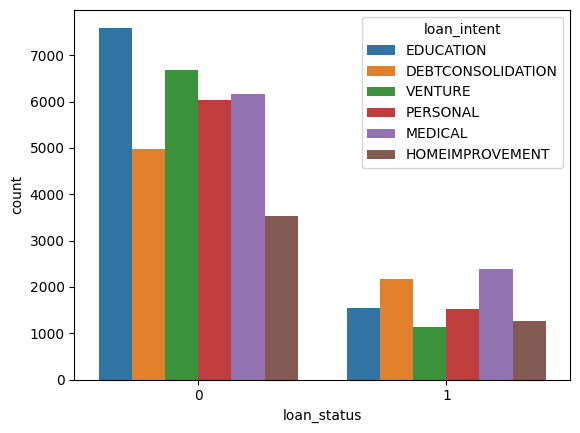

In [510]:
sns.countplot(data=df,x="loan_status",hue="loan_intent")

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

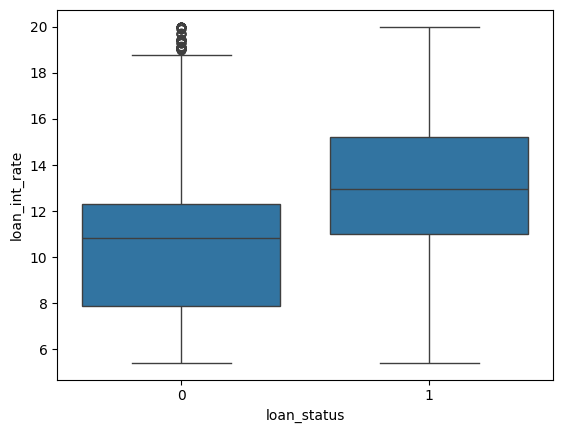

In [511]:
sns.boxplot(data=df,x="loan_status",y="loan_int_rate")

<Axes: xlabel='loan_status', ylabel='credit_score'>

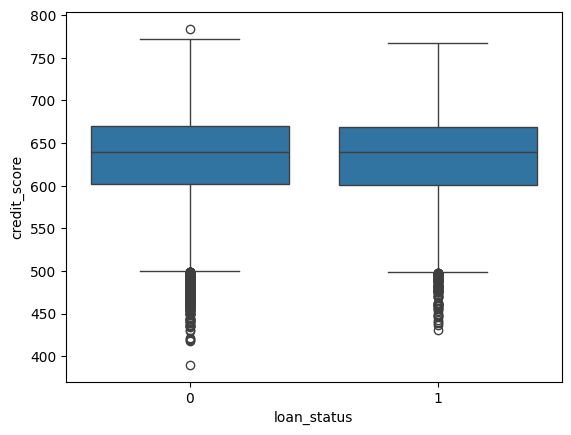

In [512]:
sns.boxplot(data=df,x="loan_status",y="credit_score")

<Axes: xlabel='loan_status', ylabel='count'>

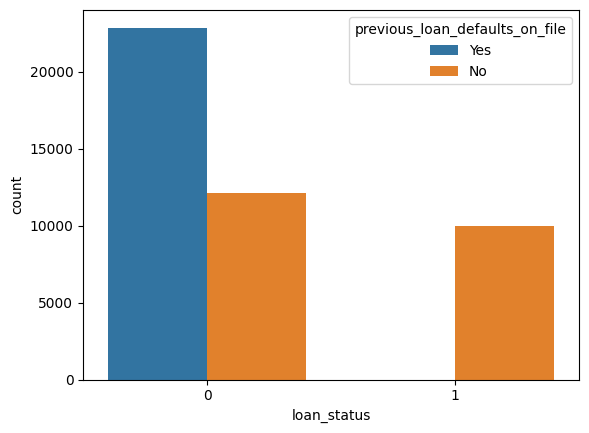

In [513]:
sns.countplot(data=df,x="loan_status",hue="previous_loan_defaults_on_file")

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

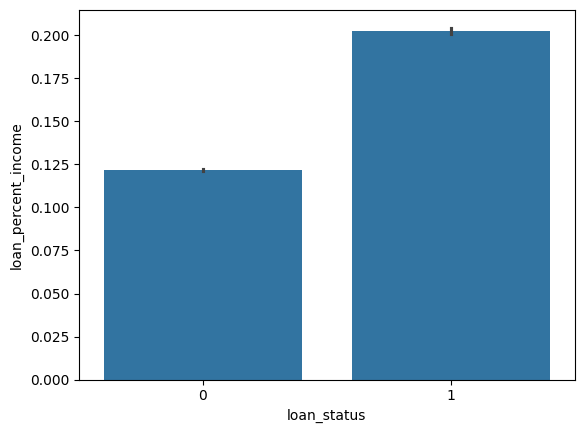

In [514]:
sns.barplot(data=df,x="loan_status",y="loan_percent_income")

From the analysis and pre processing, we found certain columns to be of neglibile importance to the data. The columns are:
1. Person Age
2. Person Gender
3. Person Employee Experience
4. Person Credit History Length

Also, we found that the dataset shows that all applicants who have a previous default on file are rejected. As such the column will be dropped for our input features. Below are two models, one with the above mentioned columns dropped and another without: model_full and model_partial.

In [515]:
def encode(df):
  df = pd.get_dummies(df,columns=["person_gender","person_education","person_home_ownership","loan_intent","previous_loan_defaults_on_file"],dtype=int)
  return df

In [516]:
enc_df = encode(df)


In [517]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [518]:
scaler_f = StandardScaler()
scaler_p = StandardScaler()
x_f = enc_df.drop(columns=["loan_status","previous_loan_defaults_on_file_No","previous_loan_defaults_on_file_Yes"])
y = enc_df["loan_status"]

x_p = enc_df.drop(columns=["person_gender_female","person_gender_male","person_emp_exp","person_age","cb_person_cred_hist_length","loan_status","previous_loan_defaults_on_file_No","previous_loan_defaults_on_file_Yes"])

In [519]:
x_train_f, x_test_f, y_train_f, y_test_f = train_test_split(x_f,y,test_size=0.2,random_state=42)
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(x_p,y,test_size=0.2,random_state=42)

In [520]:
train_scaled_f = scaler_f.fit_transform(x_train_f)
test_scaled_f = scaler_f.transform(x_test_f)

train_scaled_p = scaler_p.fit_transform(x_train_p)
test_scaled_p = scaler_p.transform(x_test_p)

In [521]:
from sklearn.linear_model import LogisticRegression

In [522]:
model_full = LogisticRegression()
model_full.fit(train_scaled_f,y_train_f)

model_partial = LogisticRegression()
model_partial.fit(train_scaled_p,y_train_p)

LogisticRegression()

In [523]:
y_pred_full = model_full.predict(test_scaled_f)
y_pred_partial = model_partial.predict(test_scaled_p)

In [524]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [525]:
acc_f = accuracy_score(y_test_f,y_pred_full)
prec_f = precision_score(y_test_f,y_pred_full)
rec_f = recall_score(y_test_f,y_pred_full)
f1_f = f1_score(y_test_f,y_pred_full)
cm_f = confusion_matrix(y_test_f,y_pred_full)

acc_p = accuracy_score(y_test_p,y_pred_partial)
prec_p = precision_score(y_test_p,y_pred_partial)
rec_p = recall_score(y_test_p,y_pred_partial)
f1_p = f1_score(y_test_p,y_pred_partial)
cm_p = confusion_matrix(y_test_p,y_pred_partial)

In [526]:
print(f"""
  Accuracy Full Model: {acc_f}\n
  Precision Full Model: {prec_f}\n
  Recall Full Model: {rec_f}\n
  F1 Score Full Model: {f1_f}\n
  Full Model Confusion Matrix:
  {cm_f}

  Accuracy Partial Model: {acc_p}\n
  Precision Partial Model: {prec_p}\n
  Recall Partial Model: {rec_p}\n
  F1 Score Partial Model: {f1_p}\n
  Partial Model Confusion Matrix:
  {cm_p}
""")


  Accuracy Full Model: 0.8484276030670075

  Precision Full Model: 0.7439759036144579

  Recall Full Model: 0.49105367793240556

  F1 Score Full Model: 0.5916167664670658

  Full Model Confusion Matrix:
  [[6647  340]
 [1024  988]]
  
  Accuracy Partial Model: 0.8484276030670075

  Precision Partial Model: 0.7436090225563909

  Recall Partial Model: 0.4915506958250497

  F1 Score Partial Model: 0.5918611609814483

  Partial Model Confusion Matrix:
  [[6646  341]
 [1023  989]]

